In [1]:
import os
import sys
import zipfile
import subprocess
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score

In [3]:
# Colab/local setup + data discovery
try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
except Exception:
    pass

if Path('/content').exists():
    REPO_ROOT = Path('/content/symAD-ECNN')
    if not REPO_ROOT.exists():
        subprocess.check_call(['git', 'clone', 'https://github.com/RifaDeen/symAD-ECNN.git', str(REPO_ROOT)])
    PROJECT_ROOT = Path('/content/drive/MyDrive/symAD-ECNN') if Path('/content/drive/MyDrive').exists() else REPO_ROOT
else:
    # local fallback (repo root inferred from notebook location)
    REPO_ROOT = Path.cwd().resolve()
    PROJECT_ROOT = REPO_ROOT

# allow importing ecnn helper
ECNN_HELPER_DIR = REPO_ROOT / 'notebooks' / 'evals' / 'ecnn_thresholding'
for p in [REPO_ROOT, ECNN_HELPER_DIR]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

DATA_DIR = Path('/content/test_eval_data/processed') if Path('/content').exists() else PROJECT_ROOT / 'data' / 'test_eval_data' / 'processed'
ZIP_PATH = PROJECT_ROOT / 'data' / 'brats_test_with_masks_processed.zip'

def has_img_mask(base: Path) -> bool:
    return (base / 'images').exists() and (base / 'masks').exists()

# If missing, extract zip
if not has_img_mask(DATA_DIR) and ZIP_PATH.exists():
    print(f'Extracting {ZIP_PATH} ...')
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        # zip contains images/, masks/, labels/, metadata.json at root
        zf.extractall(DATA_DIR)

# Resolve actual extracted folder robustly
candidates = [
    DATA_DIR,
    DATA_DIR.parent,
    DATA_DIR / 'processed',
    DATA_DIR.parent / 'processed',
    PROJECT_ROOT / 'data' / 'test_eval_data' / 'processed',
    Path('/content/test_eval_data/processed') if Path('/content').exists() else DATA_DIR,
    Path('/content/test_eval_data') if Path('/content').exists() else DATA_DIR.parent,
]

resolved = None
for c in candidates:
    if has_img_mask(c):
        resolved = c
        break

if resolved is None:
    # one-level recursive fallback
    for c in candidates:
        if c.exists():
            for sub in c.iterdir():
                if sub.is_dir() and has_img_mask(sub):
                    resolved = sub
                    break
        if resolved is not None:
            break

if resolved is None:
    raise FileNotFoundError(
        f'Expected images/masks after extraction. Checked base: {DATA_DIR} and nearby folders.'
    )

DATA_DIR = resolved
IMG_DIR = DATA_DIR / 'images'
MASK_DIR = DATA_DIR / 'masks'
print(f'Using DATA_DIR: {DATA_DIR}')

# robust pairing by stem
img_map = {fp.stem: fp for fp in IMG_DIR.glob('*.npy')}
mask_map = {fp.stem: fp for fp in MASK_DIR.glob('*.npy')}
common_keys = sorted(set(img_map.keys()) & set(mask_map.keys()))
pairs = [(img_map[k], mask_map[k]) for k in common_keys]

print(f'Paired samples: {len(pairs)}')
print(f'Image files: {len(img_map)} | Mask files: {len(mask_map)} | Common: {len(common_keys)}')
if len(pairs) == 0:
    raise RuntimeError('No paired image/mask files found.')

Extracting /content/drive/MyDrive/symAD-ECNN/data/brats_test_with_masks_processed.zip ...
Using DATA_DIR: /content/test_eval_data/processed
Paired samples: 11529
Image files: 11529 | Mask files: 11529 | Common: 11529


In [4]:
def ensure_e2cnn_installed():
    if importlib.util.find_spec('e2cnn') is not None:
        return
    print('Installing e2cnn...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'e2cnn'])

ensure_e2cnn_installed()
from ecnn_model_loader import get_model_for_inference

MODEL_PATH = PROJECT_ROOT / 'models' / 'saved_models' / 'ecnn_optimized' / 'ecnn_optimized_best.pth'
if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Checkpoint not found: {MODEL_PATH}')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model, _ = get_model_for_inference(str(MODEL_PATH), device)
model.eval()
print(f'Using device: {device}')
print(f'Model: {MODEL_PATH}')

Installing e2cnn...
Detected ECNNAutoencoderV3 checkpoint. Using latent_dim=1024.


/usr/local/lib/python3.12/dist-packages/e2cnn/nn/modules/r2_conv/basisexpansion_singleblock.py:80: UserWarning: indexing with dtype torch.uint8 is now deprecated, please use a dtype torch.bool instead. (Triggered internally at /pytorch/aten/src/ATen/native/IndexingUtils.h:37.)
  full_mask[mask] = norms.to(torch.uint8)


Model weights loaded from: /content/drive/MyDrive/symAD-ECNN/models/saved_models/ecnn_optimized/ecnn_optimized_best.pth
Using device: cuda
Model: /content/drive/MyDrive/symAD-ECNN/models/saved_models/ecnn_optimized/ecnn_optimized_best.pth


In [5]:
def normalize01(x):
    x = x.astype(np.float32)
    mn, mx = float(x.min()), float(x.max())
    if mx - mn < 1e-8:
        return np.zeros_like(x, dtype=np.float32)
    return (x - mn) / (mx - mn)

def dice_score(pred, gt):
    pred = pred.astype(np.uint8)
    gt = gt.astype(np.uint8)
    inter = (pred * gt).sum()
    return (2.0 * inter) / (pred.sum() + gt.sum() + 1e-8)

def iou_score(pred, gt):
    pred = pred.astype(np.uint8)
    gt = gt.astype(np.uint8)
    inter = (pred * gt).sum()
    union = ((pred + gt) > 0).sum()
    return inter / (union + 1e-8)

In [7]:
# Pixel-level evaluation at multiple thresholds
THRESHOLD_PERCENTILES = [90, 95, 99]  # added p90 and p99
threshold_results = {}

for pctl in THRESHOLD_PERCENTILES:
    dice_scores = []
    iou_scores = []
    pixel_aucs = []
    pixel_aucs_normalized = []
    sample_rows = []

    for img_fp, mask_fp in tqdm(pairs, total=len(pairs), desc=f'Evaluating p{pctl}'):
        img = np.load(img_fp).astype(np.float32)
        mask = np.load(mask_fp).astype(np.uint8)

        inp = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            recon = model(inp).cpu().numpy()[0, 0]

        # error map
        error_map = np.abs(img - recon).astype(np.float32)
        error_map_n = normalize01(error_map)

        # sample-wise threshold for segmentation mask prediction
        thresh = np.percentile(error_map_n, pctl)
        pred_mask = (error_map_n >= thresh).astype(np.uint8)

        has_lesion = int(mask.sum() > 0)

        # segmentation metrics are meaningful when lesion exists
        if has_lesion:
            d = dice_score(pred_mask, mask)
            j = iou_score(pred_mask, mask)
            dice_scores.append(d)
            iou_scores.append(j)

        # pixel AUROC on full image may fail for single-class gt
        try:
            pixel_aucs.append(roc_auc_score(mask.flatten(), error_map_n.flatten()))
        except Exception:
            pass

        # same AUROC over normalized map (kept separately for reporting consistency)
        try:
            pixel_aucs_normalized.append(roc_auc_score(mask.flatten(), error_map_n.flatten()))
        except Exception:
            pass

        sample_rows.append({
            'slice_id': img_fp.stem,
            'has_lesion': has_lesion,
            'mask_pixels': int(mask.sum()),
            f'threshold_p{pctl}': float(thresh),
            'dice_if_lesion': float(d) if has_lesion else np.nan,
            'iou_if_lesion': float(j) if has_lesion else np.nan,
        })

    threshold_results[pctl] = {
        'dice_scores': dice_scores,
        'iou_scores': iou_scores,
        'pixel_aucs': pixel_aucs,
        'pixel_aucs_normalized': pixel_aucs_normalized,
        'sample_rows': sample_rows,
    }

# default threshold for visualization cell below
VIS_THRESHOLD = 95

Evaluating p90:   0%|          | 0/11529 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that ca

Evaluating p95:   0%|          | 0/11529 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that ca

Evaluating p99:   0%|          | 0/11529 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that ca

In [8]:
print('=== Pixel-Level Results (Multi-threshold) ===')
print(f'Total paired samples: {len(pairs)}')

rows = []
for pctl in THRESHOLD_PERCENTILES:
    tr = threshold_results[pctl]
    dice_scores = tr['dice_scores']
    iou_scores = tr['iou_scores']
    pixel_aucs = tr['pixel_aucs']
    pixel_aucs_normalized = tr['pixel_aucs_normalized']
    sample_rows = tr['sample_rows']

    lesion_pos = sum(r['has_lesion'] for r in sample_rows)
    lesion_neg = len(sample_rows) - lesion_pos

    mean_dice = np.mean(dice_scores) if len(dice_scores) else np.nan
    std_dice = np.std(dice_scores) if len(dice_scores) else np.nan
    mean_iou = np.mean(iou_scores) if len(iou_scores) else np.nan
    mean_auc = np.mean(pixel_aucs) if len(pixel_aucs) else np.nan
    mean_auc_n = np.mean(pixel_aucs_normalized) if len(pixel_aucs_normalized) else np.nan

    print(f'\n--- p{pctl} ---')
    print(f'Lesion-positive samples: {lesion_pos}')
    print(f'Lesion-negative samples: {lesion_neg}')
    print(f'Mean Dice (lesion-positive only): {mean_dice:.4f}')
    print(f'Std Dice  (lesion-positive only): {std_dice:.4f}')
    print(f'Mean IoU  (lesion-positive only): {mean_iou:.4f}')
    print(f'Mean Pixel AUROC (available cases): {mean_auc:.4f}')
    print(f'Mean Pixel AUROC (normalized map): {mean_auc_n:.4f}')

    rows.extend([
        {'threshold_percentile': pctl, 'metric': 'mean_dice_lesion_positive', 'value': mean_dice},
        {'threshold_percentile': pctl, 'metric': 'std_dice_lesion_positive', 'value': std_dice},
        {'threshold_percentile': pctl, 'metric': 'mean_iou_lesion_positive', 'value': mean_iou},
        {'threshold_percentile': pctl, 'metric': 'mean_pixel_auroc', 'value': mean_auc},
        {'threshold_percentile': pctl, 'metric': 'mean_pixel_auroc_normalized', 'value': mean_auc_n},
    ])

results_df = pd.DataFrame(rows)
display(results_df)

# Save per-slice summaries for all thresholds + aggregated metrics
out_dir = PROJECT_ROOT / 'evaluations' / 'tables'
out_dir.mkdir(parents=True, exist_ok=True)
for pctl in THRESHOLD_PERCENTILES:
    pd.DataFrame(threshold_results[pctl]['sample_rows']).to_csv(
        out_dir / f'pixel_level_sample_summary_p{pctl}.csv', index=False
    )
results_df.to_csv(out_dir / 'pixel_level_metrics_multi_threshold.csv', index=False)
print(f'Saved: {out_dir / "pixel_level_metrics_multi_threshold.csv"}')

=== Pixel-Level Results (Multi-threshold) ===
Total paired samples: 11529

--- p90 ---
Lesion-positive samples: 7468
Lesion-negative samples: 4061
Mean Dice (lesion-positive only): 0.1413
Std Dice  (lesion-positive only): 0.1088
Mean IoU  (lesion-positive only): 0.0799
Mean Pixel AUROC (available cases): nan
Mean Pixel AUROC (normalized map): nan

--- p95 ---
Lesion-positive samples: 7468
Lesion-negative samples: 4061
Mean Dice (lesion-positive only): 0.1087
Std Dice  (lesion-positive only): 0.0984
Mean IoU  (lesion-positive only): 0.0605
Mean Pixel AUROC (available cases): nan
Mean Pixel AUROC (normalized map): nan

--- p99 ---
Lesion-positive samples: 7468
Lesion-negative samples: 4061
Mean Dice (lesion-positive only): 0.0338
Std Dice  (lesion-positive only): 0.0516
Mean IoU  (lesion-positive only): 0.0179
Mean Pixel AUROC (available cases): nan
Mean Pixel AUROC (normalized map): nan


,threshold_percentile,metric,value
0,90,mean_dice_lesion_positive,0.141270
1,90,std_dice_lesion_positive,0.108762
2,90,mean_iou_lesion_positive,0.079855
3,90,mean_pixel_auroc,NaN
4,90,mean_pixel_auroc_normalized,NaN
5,95,mean_dice_lesion_positive,0.108668
6,95,std_dice_lesion_positive,0.098436
7,95,mean_iou_lesion_positive,0.060497
8,95,mean_pixel_auroc,NaN
9,95,mean_pixel_auroc_normalized,NaN


Saved: /content/drive/MyDrive/symAD-ECNN/evaluations/tables/pixel_level_metrics_multi_threshold.csv


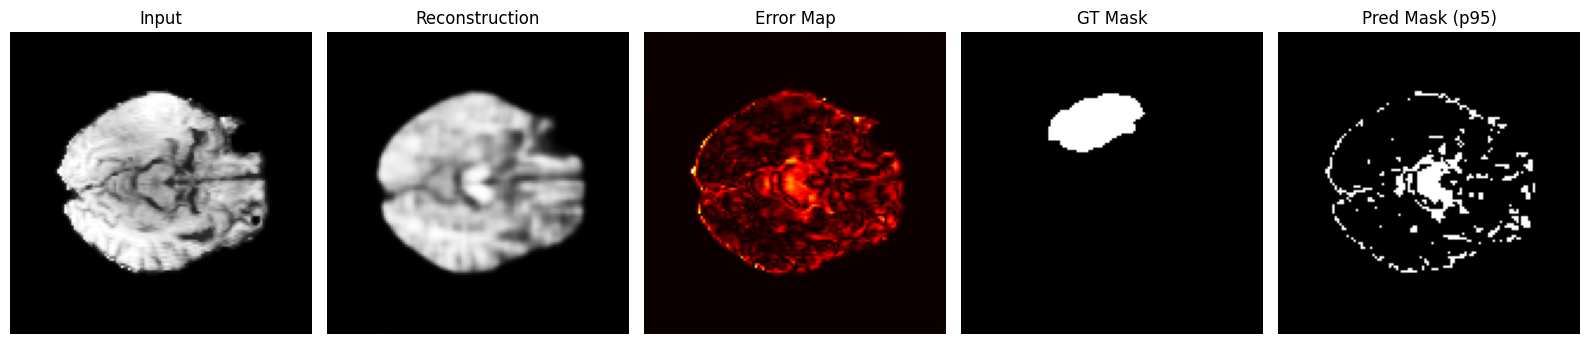

Sample: slice_000100
Has lesion: 1 | Mask pixels: 679
Dice: 0.0267 | IoU: 0.0135


In [9]:
# Visual sanity-check for one sample
idx = min(100, len(pairs) - 1)  # change index if needed

img_fp, mask_fp = pairs[idx]
img = np.load(img_fp).astype(np.float32)
mask = np.load(mask_fp).astype(np.uint8)

inp = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).to(device)
with torch.no_grad():
    recon = model(inp).cpu().numpy()[0, 0]

error_map = np.abs(img - recon).astype(np.float32)
error_map_n = normalize01(error_map)
pctl = VIS_THRESHOLD if 'VIS_THRESHOLD' in globals() else 95
thresh = np.percentile(error_map_n, pctl)
pred_mask = (error_map_n >= thresh).astype(np.uint8)

fig = plt.figure(figsize=(16, 4))

ax1 = plt.subplot(1, 5, 1)
ax1.set_title('Input')
ax1.imshow(img, cmap='gray')
ax1.axis('off')

ax2 = plt.subplot(1, 5, 2)
ax2.set_title('Reconstruction')
ax2.imshow(recon, cmap='gray')
ax2.axis('off')

ax3 = plt.subplot(1, 5, 3)
ax3.set_title('Error Map')
ax3.imshow(error_map_n, cmap='hot')
ax3.axis('off')

ax4 = plt.subplot(1, 5, 4)
ax4.set_title('GT Mask')
ax4.imshow(mask, cmap='gray')
ax4.axis('off')

ax5 = plt.subplot(1, 5, 5)
ax5.set_title(f'Pred Mask (p{pctl})')
ax5.imshow(pred_mask, cmap='gray')
ax5.axis('off')

plt.tight_layout()
plt.show()

print(f'Sample: {img_fp.stem}')
print(f'Has lesion: {int(mask.sum() > 0)} | Mask pixels: {int(mask.sum())}')
if mask.sum() > 0:
    print(f'Dice: {dice_score(pred_mask, mask):.4f} | IoU: {iou_score(pred_mask, mask):.4f}')
else:
    print('Dice/IoU skipped (empty GT mask).')